# Bearing Simulator — Exploratory Notebook

This notebook walks through the bearing signal simulator step by step.
Each cell is self-contained and produces a plot or a printed result.

**Regimes simulated:**
- `healthy` — shaft rotation harmonics + broadband noise
- `outer_race` — periodic impulses at BPFO-like frequency
- `inner_race` — periodic impulses at BPFI-like frequency
- `ball_fault` — amplitude-modulated impulse train at BSF-like frequency

**Monte Carlo nuisance group** `G_nuis`:
Amplitude ∈ [0.85, 1.15], phase ∈ [-0.3, 0.3] rad, speed ∈ [0.95, 1.05],
DC offset ∈ [-0.05, 0.05], extra noise std ∈ [0, 0.03], local dropout ∈ [0, 3%].

These are regime-preserving transformations — they do not change the operational class.
The orbit of the canonical signal under `G_nuis` defines the functional manifold M_healthy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## 1. Simulator

In [2]:
from bearing_simulator import BearingSignalSimulator

In [3]:
sim = BearingSignalSimulator()
print(f"Signal length: {len(sim.t)} samples ({sim.params.duration*1000:.0f} ms at {sim.params.fs} Hz)")
print("Simulator ready.")

Signal length: 1200 samples (100 ms at 12000 Hz)
Simulator ready.


## 2. Time domain — canonical signals and Monte Carlo envelope

The shaded band is the **orbit** of the canonical signal under `G_nuis` (p10–p90).
The solid line is the canonical signal.

This is the manifold M_regime made visible in signal space.

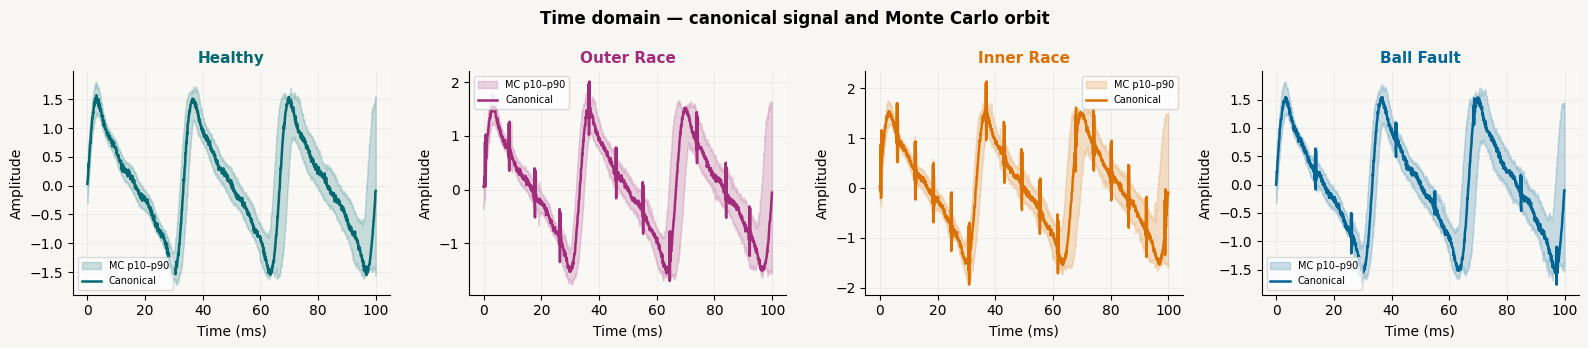

In [4]:
regimes = ["healthy", "outer_race", "inner_race", "ball_fault"]
colors  = ["#01696f", "#a12c7b", "#da7101", "#006494"]
labels  = ["Healthy", "Outer Race", "Inner Race", "Ball Fault"]
N_MC    = 50

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), facecolor="#f7f6f2")
for ax, regime, color, label in zip(axes, regimes, colors, labels):
    mc = np.array([sim.sample(regime, mc=True) for _ in range(N_MC)])
    lo, hi = np.percentile(mc, 10, axis=0), np.percentile(mc, 90, axis=0)
    canon = sim.canonical(regime)
    ax.set_facecolor("#f9f8f5")
    ax.fill_between(sim.t * 1000, lo, hi, alpha=0.2, color=color, label="MC p10–p90")
    ax.plot(sim.t * 1000, canon, color=color, lw=1.8, label="Canonical")
    ax.set_title(label, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=7, framealpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(True, alpha=0.25, lw=0.5)
fig.suptitle("Time domain — canonical signal and Monte Carlo orbit", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Frequency domain

Dashed vertical lines = shaft harmonics (30, 60, 90 … Hz).
Fault regimes inject energy at non-harmonic frequencies — the spectral signature of each fault.

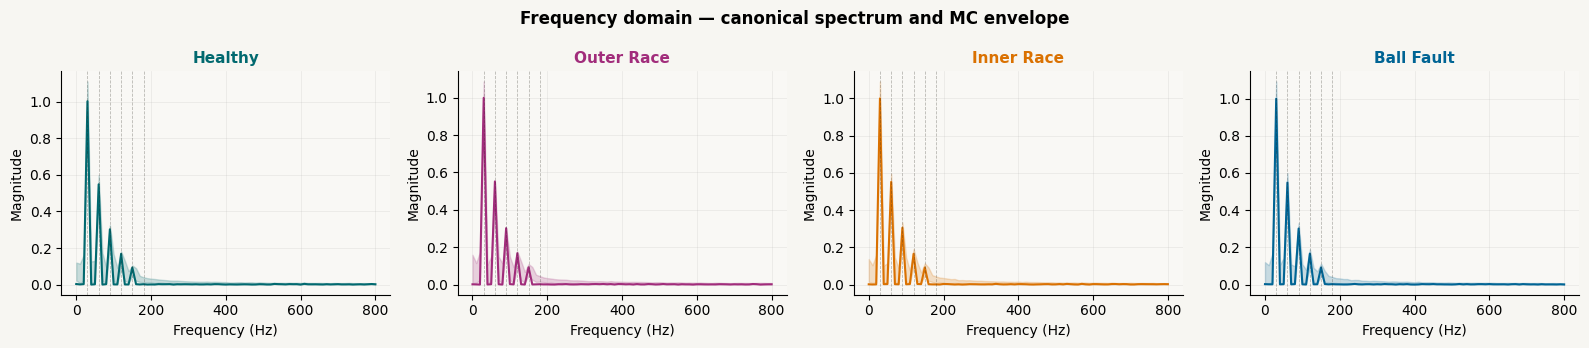

In [5]:
def fft_mag(x, fs):
    N = len(x)
    f = np.fft.rfftfreq(N, 1 / fs)
    mag = np.abs(np.fft.rfft(x)) * 2 / N
    return f, mag

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), facecolor="#f7f6f2")
for ax, regime, color, label in zip(axes, regimes, colors, labels):
    mc = np.array([sim.sample(regime, mc=True) for _ in range(N_MC)])
    mc_fft = np.array([fft_mag(s, sim.params.fs)[1] for s in mc])
    f, _ = fft_mag(mc[0], sim.params.fs)
    f_c, mag_c = fft_mag(sim.canonical(regime), sim.params.fs)
    mask = f <= 800
    lo, hi = np.percentile(mc_fft, 10, axis=0), np.percentile(mc_fft, 90, axis=0)
    ax.set_facecolor("#f9f8f5")
    ax.fill_between(f[mask], lo[mask], hi[mask], alpha=0.2, color=color)
    ax.plot(f_c[mask], mag_c[mask], color=color, lw=1.5)
    for k in range(1, 7):
        ax.axvline(k * sim.params.shaft_freq, color="#28251d", lw=0.6, alpha=0.3, ls="--")
    ax.set_title(label, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(True, alpha=0.25, lw=0.5)
fig.suptitle("Frequency domain — canonical spectrum and MC envelope", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. PCA projection — geometry of the regimes

PCA applied to raw signals (no autoencoder).

Key observation: the healthy manifold is **not a ball** — it is elongated.
This confirms that assuming a spherical boundary would be incorrect without empirical verification.
The convex hull of the healthy class is drawn to make this explicit.

Intrinsic dimension for 95% variance: 21 (out of 1200 raw dimensions)


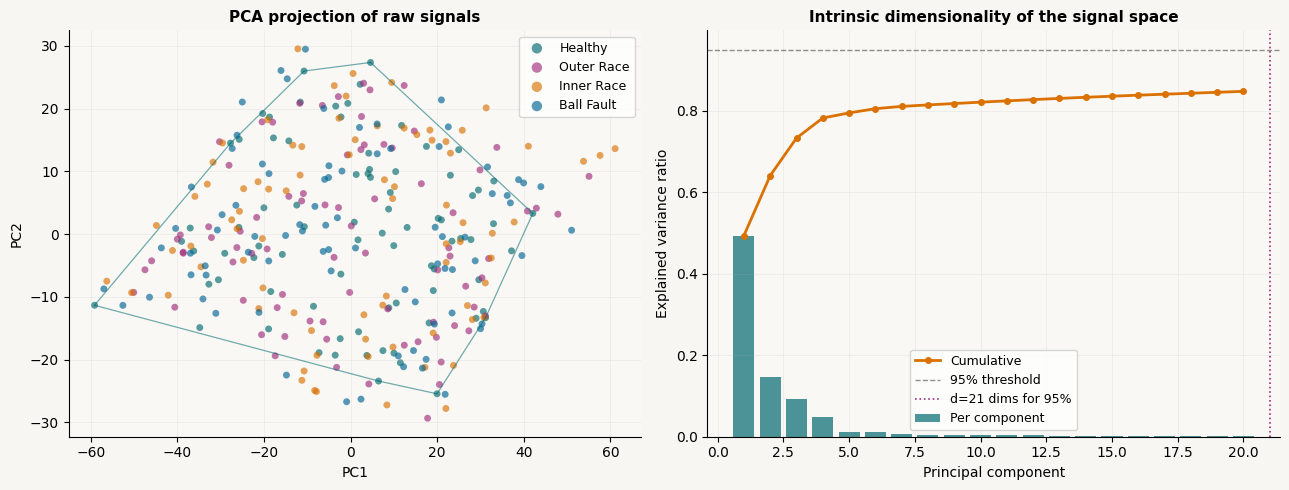

In [6]:
N_PCA = 80
all_X, all_y = [], []
for i, regime in enumerate(regimes):
    sigs = [sim.sample(regime, mc=True) for _ in range(N_PCA)]
    all_X.extend(sigs)
    all_y.extend([i] * N_PCA)

X = np.array(all_X)
y = np.array(all_y)
scaler = StandardScaler()
Z2 = PCA(n_components=2).fit_transform(scaler.fit_transform(X))
pca_full = PCA(n_components=20).fit(scaler.transform(X))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#f7f6f2")

# Left — scatter
ax = axes[0]
ax.set_facecolor("#f9f8f5")
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = y == i
    ax.scatter(Z2[mask, 0], Z2[mask, 1], c=color, s=25, alpha=0.65, label=label, edgecolors="none")
healthy_Z = Z2[y == 0]
hull = ConvexHull(healthy_Z)
for simplex in hull.simplices:
    ax.plot(healthy_Z[simplex, 0], healthy_Z[simplex, 1], color=colors[0], lw=0.9, alpha=0.55)
ax.set_title("PCA projection of raw signals", fontsize=11, fontweight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=9, framealpha=0.8, markerscale=1.5)
ax.spines[["top","right"]].set_visible(False)
ax.grid(True, alpha=0.2, lw=0.5)

# Right — explained variance
ax2 = axes[1]
ax2.set_facecolor("#f9f8f5")
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax2.bar(range(1, len(cum_var)+1), pca_full.explained_variance_ratio_, color=colors[0], alpha=0.7, label="Per component")
ax2.plot(range(1, len(cum_var)+1), cum_var, color=colors[2], lw=2, marker="o", markersize=4, label="Cumulative")
ax2.axhline(0.95, color="#28251d", lw=1, ls="--", alpha=0.5, label="95% threshold")
d95 = np.searchsorted(cum_var, 0.95) + 1
ax2.axvline(d95, color="#a12c7b", lw=1.2, ls=":" , label=f"d={d95} dims for 95%")
ax2.set_title("Intrinsic dimensionality of the signal space", fontsize=11, fontweight="bold")
ax2.set_xlabel("Principal component")
ax2.set_ylabel("Explained variance ratio")
ax2.legend(fontsize=9, framealpha=0.8)
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(True, alpha=0.2, lw=0.5)
print(f"Intrinsic dimension for 95% variance: {d95} (out of {X.shape[1]} raw dimensions)")
plt.tight_layout()
plt.show()

## 5. Manifold radius saturation (Blueprint Saturation criterion)

For each regime, we measure the p95 radius of the point cloud in PCA space
as a function of the number of samples.

**Expected result:** the radius stabilizes before ~80–100 samples.
This is the empirical signature of manifold compactness — the functional structure
is recoverable from scarce observations.

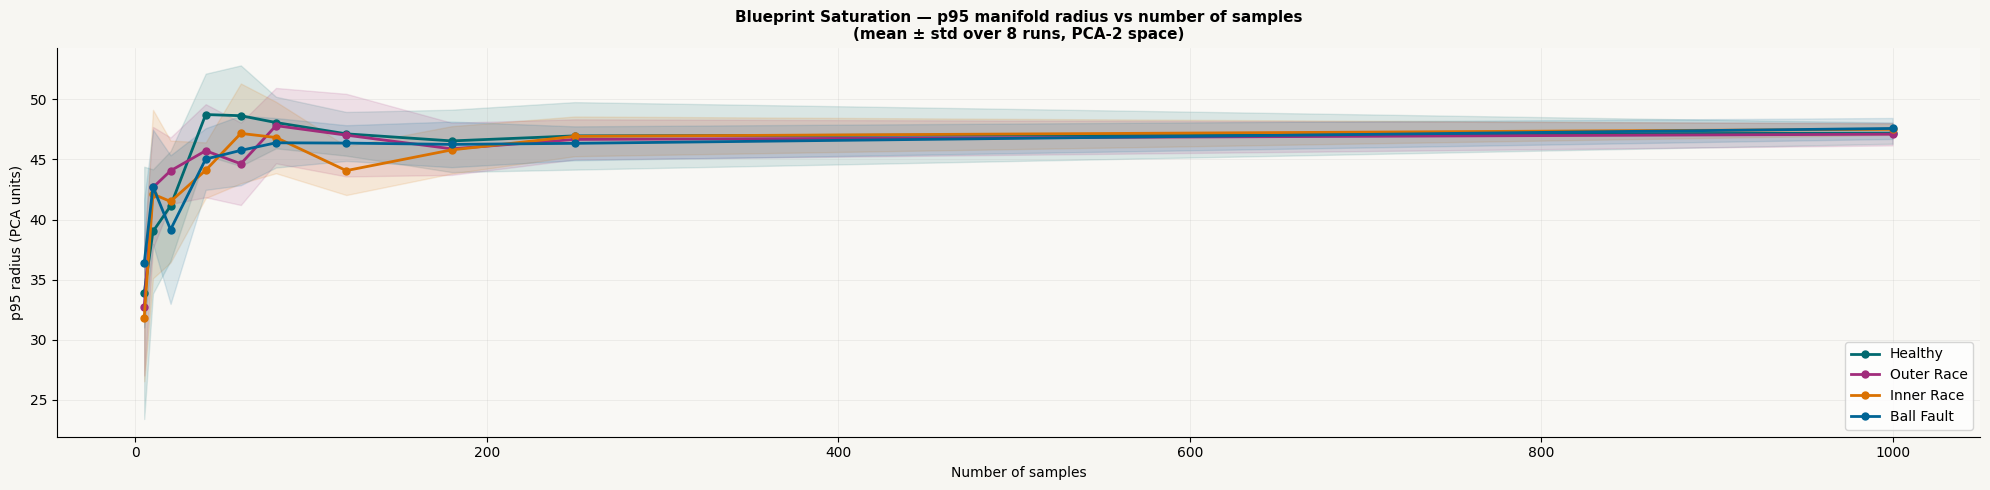

In [7]:
pca2 = PCA(n_components=2).fit(scaler.transform(X))
sample_sizes = [5, 10, 20, 40, 60, 80, 120, 180, 250, 1000]
N_RUNS = 8   # average over multiple draws to reduce variance

fig, ax = plt.subplots(figsize=(20, 5), facecolor="#f7f6f2")
ax.set_facecolor("#f9f8f5")

for regime, color, label in zip(regimes, colors, labels):
    mean_radii, std_radii = [], []
    for n in sample_sizes:
        run_radii = []
        for _ in range(N_RUNS):
            sigs = np.array([sim.sample(regime, mc=True) for _ in range(n)])
            z = pca2.transform(scaler.transform(sigs))
            mu = z.mean(axis=0)
            r = np.percentile(np.linalg.norm(z - mu, axis=1), 95)
            run_radii.append(r)
        mean_radii.append(np.mean(run_radii))
        std_radii.append(np.std(run_radii))
    mean_radii = np.array(mean_radii)
    std_radii  = np.array(std_radii)
    ax.plot(sample_sizes, mean_radii, color=color, lw=2, marker="o", markersize=5, label=label)
    ax.fill_between(sample_sizes, mean_radii - std_radii, mean_radii + std_radii, alpha=0.12, color=color)

ax.set_title("Blueprint Saturation — p95 manifold radius vs number of samples\n(mean ± std over 8 runs, PCA-2 space)", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of samples")
ax.set_ylabel("p95 radius (PCA units)")
ax.legend(fontsize=10, framealpha=0.8)
ax.spines[["top","right"]].set_visible(False)
ax.grid(True, alpha=0.25, lw=0.5)
plt.tight_layout()
plt.show()